Python Notebook to implement MASC algorithm on the Document dataset.

# Import Packages

In [1]:
import numpy as np
import random
import pandas as pd
from scipy import stats
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import connected_components
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from scipy.special import jacobi
from scipy.special import loggamma
import pathlib
from sklearn.feature_extraction.text import TfidfVectorizer
import sklearn.preprocessing
import copy
from sklearn import metrics
import csv
import scipy

# Import and Setup Data

In [ ]:
categories_dir=list(pathlib.Path(r"PATH TO YOUR DATA FILE DIRECTORY HERE, for example: C:\Users\generic_user\Documents\Python\MASC\Document\data").iterdir())
print(categories_dir)

corpus_paths=[]
for cat in categories_dir:
    for file_loc in list(cat.iterdir()):
        corpus_paths.append(file_loc)

corpus=[]
for path in corpus_paths:
    with open(path, errors='ignore') as f_input:
        corpus.append(f_input.read())

[WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/business'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/entertainment'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/food'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/graphics'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/historical'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/medical'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/politics'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/space'), WindowsPath('C:/Users/ryanm/OneDrive/Documents/Python/Classification/Document_Classification/data/sport'), WindowsPath('

Vectorize documents

In [4]:
vectorizer = TfidfVectorizer(max_df=.1,min_df=.02)

X = vectorizer.fit_transform(corpus).toarray()
features=vectorizer.get_feature_names_out()
print(X.shape, X)

(1000, 1684) [[0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.10217311 0.         0.        ]
 ...
 [0.         0.         0.         ... 0.         0.         0.        ]
 [0.         0.         0.         ... 0.06013303 0.06327478 0.        ]
 [0.         0.         0.         ... 0.         0.         0.        ]]


In [5]:
y=np.repeat([1, 2, 3, 4, 5, 6, 7, 8, 9, 10], 100)

Get size of training set and classes. Print number of points belonging to each class.

In [6]:
trainsize=1000
train=X
target=y.T[0]
target=np.asarray(y)
classes=np.sort(list(dict.fromkeys(target)))
print(f"Vector of class labels: {classes}")
for i in classes:
    print(f"Number of points in class {i}: {len(np.where(target==i)[0])}")

Vector of class labels: [ 1  2  3  4  5  6  7  8  9 10]
Number of points in class 1: 100
Number of points in class 2: 100
Number of points in class 3: 100
Number of points in class 4: 100
Number of points in class 5: 100
Number of points in class 6: 100
Number of points in class 7: 100
Number of points in class 8: 100
Number of points in class 9: 100
Number of points in class 10: 100


Define Data matrices on the sphere.

1.0 0.9872371220121045
0.15993823355236444 0.0


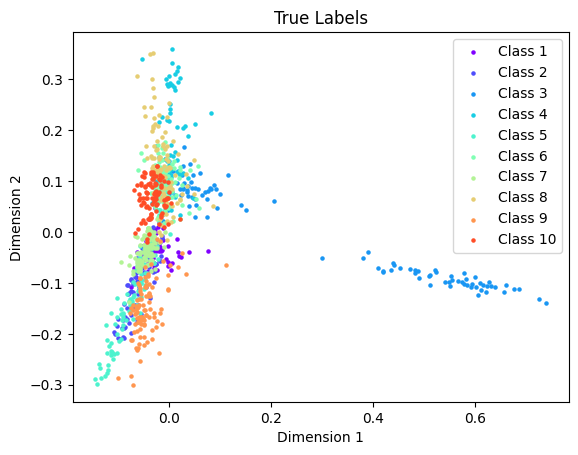

In [7]:
# #Translate Training Data to have range centered at zero
avg=(np.max(train, axis=0)+np.min(train, axis=0))/2
traincen=train-avg

#traincen=svdtrain

#Project Data to the sphere with hyperparameter alpha in (0,2]
alpha=1
maxnorm=np.max(np.linalg.norm(traincen, axis=1))
scaledtrain=alpha*traincen/maxnorm #1.5 can be changed to any value <=2 to control spread of data
r=np.linalg.norm(scaledtrain, axis=1)
trainsph=np.hstack((((4*(scaledtrain.T*r).T).T/((4+r**2)*r)).T,((4-r**2)/(4+r**2)).reshape(trainsize,1)))
normsph=np.linalg.norm(trainsph, axis=1)

#Matrix of angles between points
sphmat=np.matmul(trainsph,np.transpose(trainsph))
#this line is for slight rounding error causing out-of-bounds for arccos
sphmat[sphmat>1]=1

#Matrix of spherical distance between points
distmat=np.arccos(sphmat)
print(sphmat.max(),sphmat.min())
print(distmat.max(),distmat.min())

mean=np.mean(train,axis=0)
centeredtrain=train-mean
uu, ss, vv=np.linalg.svd(centeredtrain)
plotdim1=np.matmul(np.asarray(centeredtrain),vv[0])
plotdim2=np.matmul(np.asarray(centeredtrain),vv[1])
c=cm.rainbow(np.linspace(0,1,len(classes)+1))
for i in classes:
    plt.scatter(plotdim1[np.where(target==i)[0]],plotdim2[np.where(target==i)[0]],s=5,color=c[i-1],label=f"Class {i}")
plt.title('True Labels')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()

# Define Localized Kernels

Positive Chebyshev Kernel for use with support estimation. Included is a piecewise linear estimation of the kernel for improved run-times.

In [9]:
#defining the half-pass filter
def h(t):
    t = np.abs(t)
    out = np.zeros_like(t)
    for i in range(len(t)):
        if t[i] <= 1/2:
            out[i] = 1
        elif (1/2 < np.abs(t[i])) and (np.abs(t[i]) < 1):
            out[i] = np.exp(-np.exp(2/(1-2*t[i]))/(1-t[i]))
        else:
            out[i] = 0
    return out

#Phi Kernel Definition
def Phi(n,x):
    out=1/(2*np.pi)
    for k in np.arange(1,n,1):
        out+=h([k/n])*np.cos(k*np.arccos(x))/np.pi
    out=out**2
    return out

def Phiapprox(n,x,numinterp):
    xdir=x.shape[0]
    if x.ndim==1:
        ydir=1
    if x.ndim==2:
        ydir=x.shape[1]
    xlist=np.vstack((x.reshape(1,xdir*ydir),np.arange(xdir*ydir)))
    phivals=1-2*(1/2-np.linspace(-1,1,numinterp)/2)**(n/2)
    phivec=Phi(n,phivals)
    newmat=np.zeros((xdir*ydir,1))
    for i in np.arange(1,numinterp,1):
        ind=xlist[0]<=phivals[i]
        newmat[xlist[1][ind].astype(int)]=(phivec[i-1]+(xlist[0][ind]-phivals[i-1])*(phivec[i]-phivec[i-1])/(phivals[i]-phivals[i-1])).reshape(ind.sum(),1)
        xlist=np.delete(xlist, ind, 1)
    newmat=np.reshape(newmat,(xdir,ydir))
    return newmat

# MASC Algorithm

Generate Phimat matrix for thresholding and querying.

In [ ]:
n=128
Phimat=Phiapprox(n,sphmat,100)
Phisum=np.sum(Phimat,axis=0)

Theta thresholding.

In [10]:
Theta=1

#percentage of data to be captured
datathreshold=1
verticescount=0

while verticescount<datathreshold*trainsize:
    Theta=Theta-.0001
    vertex_list=np.where(Phisum>Theta*Phisum.max())[0]
    verticescount=len(vertex_list)
    
# Theta=0
# vertex_list=np.where(Phisum>Theta*Phisum.max())[0]
# verticescount=len(vertex_list)

#distmat for only those points
distmat_sheared=distmat[vertex_list][:,vertex_list]
print(Theta,verticescount)

0.5109000000000539 1000


This cell gives the number of clusters of size p from the thresholded data set for a fixed eta value. Use of this cell is to determine good lower and upper limits for the eta loop in the next cell.

In [11]:
eta=.082
adjmat=np.zeros([verticescount, verticescount])
adjmat[distmat_sheared<eta]=1
adjmat=adjmat-np.identity(len(vertex_list))

#Compute Graph components
graph=csr_matrix(adjmat)
num_components, componentlist = connected_components(csgraph=graph, directed=False, return_labels=True)

#Trim components. Any components of size smaller than this value will be removed from list by setting their component to -1
componentthreshold=3
componentnum, componentsizes=np.unique(componentlist, return_counts="True")
bigcomponents=np.where(componentsizes>componentthreshold)[0]
sheared_componentlist=componentlist[np.isin(componentlist,bigcomponents)]
sheared_componentnum, sheared_componentsizes=np.unique(sheared_componentlist, return_counts="True")

print(sheared_componentnum,sheared_componentsizes)

[299 663] [7 4]


Eta for loop of MASC algorithm.

In [ ]:
predict_labels=np.zeros(trainsize)
A=[]
B=[]
indlist=[]

querycount=0
numqueries=[]
etatrack=[]
MASClist=[]

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0], indmat

for eta in np.arange(.08,.15,.002):
    #Adjacency matrix for sheared points
    adjmat=np.zeros([verticescount, verticescount])
    adjmat[distmat_sheared<eta]=1
    adjmat=adjmat-np.identity(len(vertex_list))

    #Compute Graph components
    graph=csr_matrix(adjmat)
    num_components, componentlist = connected_components(csgraph=graph, directed=False, return_labels=True)

    #Trim components. Any components of size smaller than this value will be removed from list by setting their component to -1
    componentthreshold=3
    componentnum, componentsizes=np.unique(componentlist, return_counts="True")
    bigcomponents=np.where(componentsizes>componentthreshold)[0]
    sheared_componentlist=componentlist[np.isin(componentlist,bigcomponents)]
    sheared_componentnum, sheared_componentsizes=np.unique(sheared_componentlist, return_counts="True")

    #Find modal points in each cluster to query true class label. keep track of x_i and y_i from each.
    for i in sheared_componentnum: # np.arange(0,num_components):
        componentset=vertex_list[np.where(componentlist==i)[0]]
        if np.intersect1d(A,componentset).size==0:

            x_i=componentset[np.argmax(Phisum[componentset])]
            y_i=target[x_i]
            A.append(x_i)
            B.append(y_i)
            predict_labels[componentset]=y_i

            #uncomment this code and comment the above code to query multiple points per cluster
            # querysize=np.max((round(componentset.size*.05),1))
            # queryargs=np.argpartition(Phisum[componentset], -querysize)[-querysize:]
            # modalpoint=stats.mode(target[componentset[queryargs]])[0]
            # y_i=modalpoint
            # for x_i in componentset[queryargs]:
            #     A.append(x_i)
            #     B.append(target[x_i])
            #     predict_labels[x_i]=target[x_i]
            # predict_labels[np.setdiff1d(componentset,componentset[queryargs])]=y_i
            
        elif np.size(np.unique(np.intersect1d(A,componentset)))==1:
            predict_labels[componentset]=target[np.unique(np.intersect1d(A,componentset))[0]]

    
    if len(A)>querycount+5:
        querycount=len(A)
        labels=copy.deepcopy(predict_labels)
        predict_labels_ind=np.where(predict_labels)[0]
        indlist.append(predict_labels_ind)
        extensionmat=sphmat[predict_labels_ind,:]
        extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
        newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],25)
        labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

        truthcheck3=target==labels
        correctnum3=len(np.where(truthcheck3)[0])
        print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")
        MASClist.append(correctnum3/trainsize)
        numqueries.append(len(A))
        etatrack.append(eta)
            



predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind].T==predict_labels[predict_labels_ind]

print(f"List of classes in the prediction: {np.setdiff1d(list(dict.fromkeys(predict_labels)),[0])}")
print(f"Number of points queried: {len(A)}")
predict_labels_ind=np.where(predict_labels)[0]
truthcheck=target[predict_labels_ind]==predict_labels[predict_labels_ind]
correctnum=len(np.where(truthcheck)[0])
totalnum=len(predict_labels_ind)
print(f"Number of points classified: {totalnum}")
print(f"Number of correctly classified points of those classified: {correctnum} ({100*correctnum/totalnum:.2f}%)")

labels=copy.deepcopy(predict_labels)
predict_labels_ind=np.where(predict_labels)[0]
extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],25)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points and queries: {correctnum3} ({100*correctnum3/trainsize:.2f}%), {len(A)}")

Number of correctly classified points and queries: 417 (41.70%), 10
Number of correctly classified points and queries: 556 (55.60%), 18
Number of correctly classified points and queries: 659 (65.90%), 25
Number of correctly classified points and queries: 776 (77.60%), 31
Number of correctly classified points and queries: 814 (81.40%), 38
Number of correctly classified points and queries: 856 (85.60%), 45
Number of correctly classified points and queries: 873 (87.30%), 51
List of classes in the prediction: [ 1.  2.  3.  4.  5.  6.  7.  8.  9. 10.]
Number of points queried: 51
Number of points classified: 441
Number of correctly classified points of those classified: 427 (96.83%)
Number of correctly classified points and queries: 874 (87.40%), 51


<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ryanm\AppData\Local\Temp\ipykernel_7204\3280123724.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.scatter(plotdim1[indlist[len(indlist)-i-1]],plotdim2[indlist[len(indlist)-i-1]],s=10,color=c2[i],label=f"Iter. {len(indlist)-i} (#Queries: {numqueries[len(indlist)-i-1]}, $\eta$: {etatrack[len(indlist)-i-1]:.3f})")


(-0.2, 0.8)

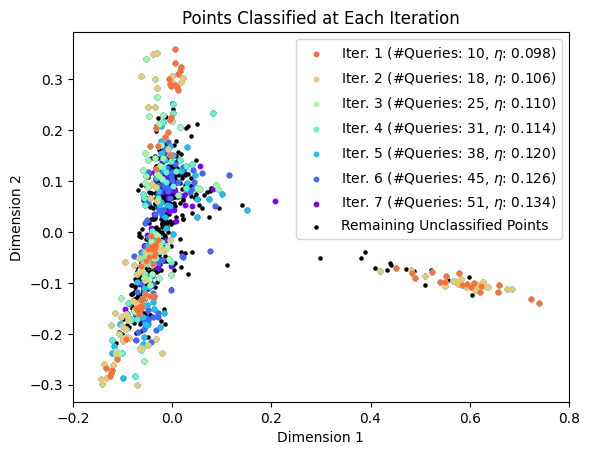

In [38]:
# f = plt.figure()
# f.set_figwidth(8)
# f.set_figheight(5.5)
c2=cm.rainbow(np.linspace(0,1,len(indlist)+1))
plt.scatter(plotdim1,plotdim2,s=5,color='black',label="Remaining Unclassified Points")
for i in range(len(indlist)):
    plt.scatter(plotdim1[indlist[len(indlist)-i-1]],plotdim2[indlist[len(indlist)-i-1]],s=10,color=c2[i],label=f"Iter. {len(indlist)-i} (#Queries: {numqueries[len(indlist)-i-1]}, $\eta$: {etatrack[len(indlist)-i-1]:.3f})")

plt.title('Points Classified at Each Iteration')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles[::-1], labels[::-1])
plt.xlim([-.2,.8])

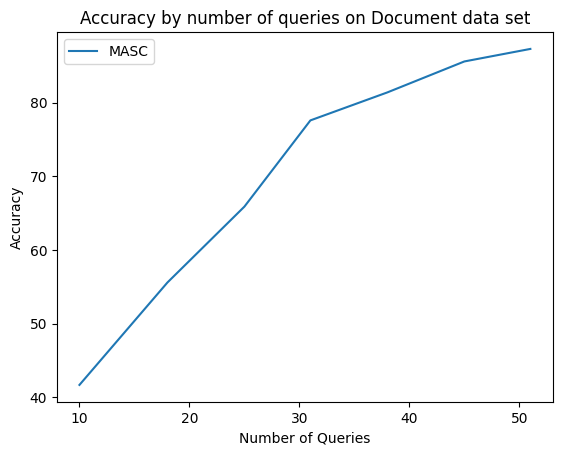

In [ ]:
plt.plot(numqueries,[i*100 for i in MASClist],label="MASC")
plt.title('Accuracy by number of queries on Document data set')
plt.xlabel('Number of Queries')
plt.ylabel('Accuracy')
plt.legend()

Plot output from MASC algorithm before KNN extension.

559


<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
<>:7: SyntaxWarning: invalid escape sequence '\T'
<>:7: SyntaxWarning: invalid escape sequence '\e'
C:\Users\ryanm\AppData\Local\Temp\ipykernel_22212\1577618279.py:7: SyntaxWarning: invalid escape sequence '\T'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.08,0.14]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
C:\Users\ryanm\AppData\Local\Temp\ipykernel_22212\1577618279.py:7: SyntaxWarning: invalid escape sequence '\e'
  plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.08,0.14]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')


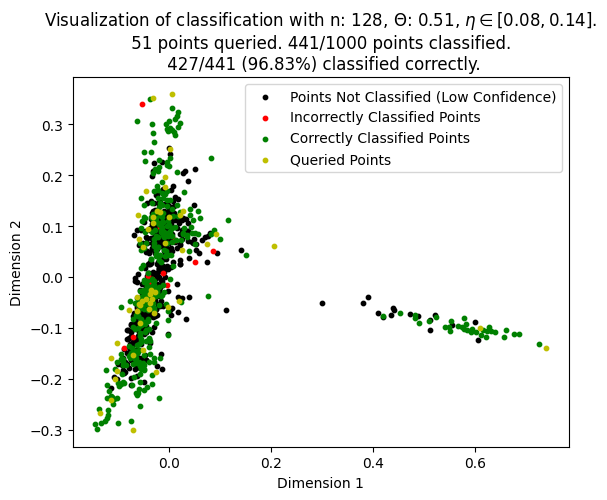

In [13]:
falsepoints=predict_labels_ind[np.where(truthcheck==False)[0]]
truepoints=predict_labels_ind[np.where(truthcheck)[0]]
plt.scatter(plotdim1[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)],plotdim2[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind),],s=10,color="black", label=f"Points Not Classified (Low Confidence)")
plt.scatter(plotdim1[falsepoints],plotdim2[falsepoints],s=10,color="r",label=f"Incorrectly Classified Points")
plt.scatter(plotdim1[np.setdiff1d(truepoints,A)],plotdim2[np.setdiff1d(truepoints,A)],color="g",s=10,label=f"Correctly Classified Points")
plt.scatter(plotdim1[A],plotdim2[A],color="y",s=10,label=f"Queried Points")
plt.title(f'Visualization of classification with n: {n}, $\Theta$: {Theta:.2f}, $\eta\in [0.08,0.14]$.\n {len(A)} points queried. {totalnum}/{trainsize} points classified. \n {correctnum}/{totalnum} ({100*correctnum/totalnum:.2f}%) classified correctly.')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

print(len(np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)))

# Show the plot
plt.show()

# Knn extension

In [89]:
labels=np.zeros((trainsize,))
randinds=random.sample(range(trainsize),51)
labels[randinds]=target[randinds]
predict_labels_ind=np.where(labels)[0]

In [90]:
# labels=copy.deepcopy(predict_labels)

def Knearest(X,label,K):
    indmat=np.argpartition(-X, K, axis=0)[:K]
    labelsmasked=label[indmat]
    return scipy.stats.mode(labelsmasked, keepdims=True)[0], indmat

#print()
extensionmat=sphmat[predict_labels_ind,:]
extensionmat=extensionmat[:,np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]
newlabels,indmat=Knearest(extensionmat,labels[predict_labels_ind],3)
labels[np.setdiff1d(np.arange(0,trainsize),predict_labels_ind)]=newlabels

truthcheck3=target==labels
correctnum3=len(np.where(truthcheck3)[0])
print(f"Number of correctly classified points: {correctnum3} ({100*correctnum3/trainsize:.2f}%)")

Number of correctly classified points: 709 (70.90%)


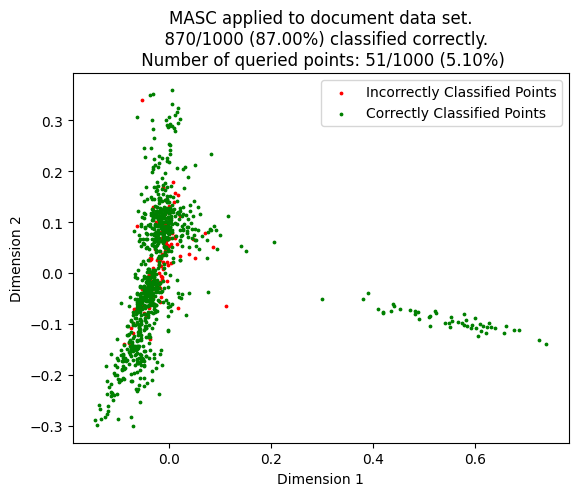

In [16]:
plt.scatter(plotdim1[np.where(truthcheck3==False)[0]],plotdim2[np.where(truthcheck3==False)[0]],s=3,color="r",label=f"Incorrectly Classified Points")
plt.scatter(plotdim1[np.where(truthcheck3)[0]],plotdim2[np.where(truthcheck3)[0]],color="g",s=3,label=f"Correctly Classified Points")
plt.title(f'MASC applied to document data set.\n  {correctnum3}/{trainsize} ({100*correctnum3/trainsize:.2f}%) classified correctly.\n Number of queried points: {len(A)}/{trainsize} ({100*(len(A)/trainsize):.2f}%)')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()

Generate confusion matrix.

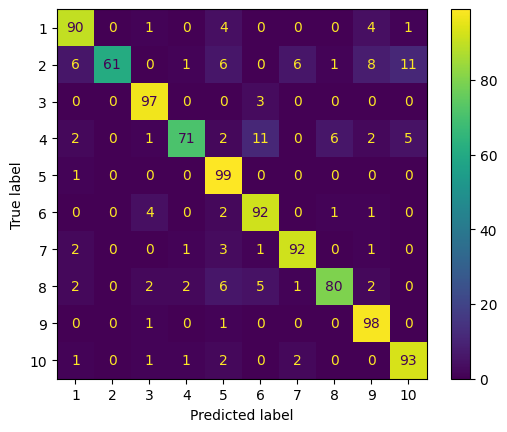

In [48]:
conf_matrix=metrics.confusion_matrix(target,labels)
disp=metrics.ConfusionMatrixDisplay(conf_matrix,display_labels=classes.astype(int))
disp.plot()

Generate predicted labels scatterplot.

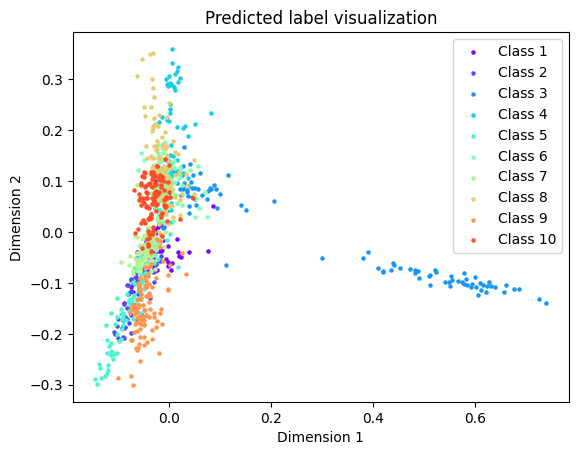

In [ ]:
c=cm.rainbow(np.linspace(0,1,len(classes)+1))
for i in classes:
    plt.scatter(plotdim1[np.where(labels==i)[0]],plotdim2[np.where(labels==i)[0]],s=5,color=c[i-1],label=f"Class {i}")
plt.title('Predicted label visualization')
plt.xlabel('Dimension 1')
plt.ylabel('Dimension 2')
plt.legend()

# Show the plot
plt.show()